In [1]:
# import warnings is simply used to remove warnings about incompatibility with future Pandas update on Nate's device
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
from BH_func_run_all_functions import *
import pandas as pd
from ipynb.fs.defs.NG_offtaker_working_file import (construct_calendar_year_list, 
                                                    construct_business_case_year_list, 
                                                    construct_operations_years_list, 
                                                    construct_decomissioning_years_list, 
                                                    construction_phase,
                                                    operational_phase,
                                                    decommissioning_phase,
                                                    taxes_and_profits_part1,
                                                    debt_and_loan_part1,
                                                    taxes_and_profits_part2,
                                                    debt_and_loan_part2,
                                                    project_reserves,
                                                    equity_funding,
                                                    present_value_cashflows,
                                                    cumulative_equity_and_debt_cashflows,
                                                    discounted_cashflows_for_levelized_cost,
                                                    levelized_cost_and_revenues,
                                                    project_kpi,
                                                    equity_kpi,
                                                    output_kpi)
from NG_input_data import *
from NG_func_run_all_functions import ng_run_all_functions
import importlib
import NG_input_data
from NSE_get_data_from_ESDL import *

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl


In [3]:
file_names = ["TNVDW_cost_single_units_v1_pessimistic_scenario.esdl", "TNVDW_cost_single_units_v1_most_likely_scenario.esdl", "TNVDW_cost_single_units_v1_optimistic_scenario.esdl"]

# make a dataframe that will contain the levelized costs and revenues from all scenarios    
# Define the levels of the MultiIndex
groups = ['Pessimistic', 'Most likely', 'Optimistic']  # Group names
sub_columns = ['Costs', 'Avoided costs']  # Sub-column names

# Create the MultiIndex from the groups and sub_columns
multi_index = pd.MultiIndex.from_product([groups, sub_columns], names=['Scenario', 'Type'])

# Create an empty DataFrame with the multi-level columns
df_lcr_all_scenarios = pd.DataFrame(columns=multi_index)

# Make a dataframe that will contain all kpi results
df_kpi_results = pd.DataFrame(columns=['Pessimistic', 'Most likely', 'Optimistic', 'Unit'])


for x in file_names:

    esh = EnergySystemHandler()
    esh.load_file(x)
    energy_system = esh.get_energy_system()
    instance_list = energy_system.instance
    my_instance = instance_list[0]

    if x == file_names[0]:
        drop_scenarios = ['most_likely','optimistic']
    elif x == file_names[1]:
        drop_scenarios = ['pessimistic','optimistic']
    else: 
        drop_scenarios = ['pessimistic','most_likely']

    save_to_pickle(drop_scenarios, asset_parameters)
     
    importlib.reload(NG_input_data)    

    ng_run_all_functions(NG_input_data.ot_capex_h2_receiving_station,
                         NG_input_data.ot_capex_h2_pipeline,
                         NG_input_data.df_h2_boiler_capex,
                         NG_input_data.df_ng_boiler_capex,
                         NG_input_data.df_h2_boiler_opex,
                         NG_input_data.ot_network_costs_h2,
                         NG_input_data.ot_h2_price,
                         NG_input_data.ot_hwi_costs,
                         NG_input_data.df_ng_boiler_opex,
                         NG_input_data.ot_network_costs_ng,
                         NG_input_data.ot_carbon_permits,
                         NG_input_data.ot_ng_price,
                         NG_input_data.ot_ng_tax_cost,
                         NG_input_data.ot_inflation,
                         NG_input_data.ot_loan_percentage,
                         NG_input_data.ot_loan_interest_rate,
                         NG_input_data.ot_income_tax_rate,
                         NG_input_data.ot_general_WACC,
                         NG_input_data.ot_h2_boiler_lifetime)
    
    
    levelized_cost = levelized_cost_and_revenues(NG_input_data.ot_capex_h2_receiving_station,
                                                NG_input_data.ot_capex_h2_pipeline,
                                                NG_input_data.df_h2_boiler_capex,
                                                NG_input_data.df_ng_boiler_capex,
                                                NG_input_data.df_h2_boiler_opex,
                                                NG_input_data.ot_network_costs_h2,
                                                NG_input_data.ot_h2_price,
                                                NG_input_data.ot_hwi_costs,
                                                NG_input_data.df_ng_boiler_opex,
                                                NG_input_data.ot_network_costs_ng,
                                                NG_input_data.ot_carbon_permits,
                                                NG_input_data.ot_ng_price,
                                                NG_input_data.ot_ng_tax_cost,
                                                NG_input_data.ot_inflation,
                                                NG_input_data.ot_loan_percentage,
                                                NG_input_data.ot_loan_interest_rate,
                                                NG_input_data.ot_income_tax_rate,
                                                NG_input_data.ot_general_WACC,
                                                NG_input_data.ot_h2_boiler_lifetime)

    project_result = project_kpi(NG_input_data.ot_capex_h2_receiving_station,
                                NG_input_data.ot_capex_h2_pipeline,
                                NG_input_data.df_h2_boiler_capex,
                                NG_input_data.df_ng_boiler_capex,
                                NG_input_data.df_h2_boiler_opex,
                                NG_input_data.ot_network_costs_h2,
                                NG_input_data.ot_h2_price,
                                NG_input_data.ot_hwi_costs,
                                NG_input_data.df_ng_boiler_opex,
                                NG_input_data.ot_network_costs_ng,
                                NG_input_data.ot_carbon_permits,
                                NG_input_data.ot_ng_price,
                                NG_input_data.ot_ng_tax_cost,
                                NG_input_data.ot_inflation,
                                NG_input_data.ot_loan_percentage,
                                NG_input_data.ot_loan_interest_rate,
                                NG_input_data.ot_income_tax_rate,
                                NG_input_data.ot_general_WACC,
                                NG_input_data.ot_h2_boiler_lifetime)
    
    equity_result = equity_kpi(NG_input_data.ot_capex_h2_receiving_station,
                                NG_input_data.ot_capex_h2_pipeline,
                                NG_input_data.df_h2_boiler_capex,
                                NG_input_data.df_ng_boiler_capex,
                                NG_input_data.df_h2_boiler_opex,
                                NG_input_data.ot_network_costs_h2,
                                NG_input_data.ot_h2_price,
                                NG_input_data.ot_hwi_costs,
                                NG_input_data.df_ng_boiler_opex,
                                NG_input_data.ot_network_costs_ng,
                                NG_input_data.ot_carbon_permits,
                                NG_input_data.ot_ng_price,
                                NG_input_data.ot_ng_tax_cost,
                                NG_input_data.ot_inflation,
                                NG_input_data.ot_loan_percentage,
                                NG_input_data.ot_loan_interest_rate,
                                NG_input_data.ot_income_tax_rate,
                                NG_input_data.ot_general_WACC,
                                NG_input_data.ot_h2_boiler_lifetime)

    output_result = output_kpi(NG_input_data.ot_capex_h2_receiving_station,
                                NG_input_data.ot_capex_h2_pipeline,
                                NG_input_data.df_h2_boiler_capex,
                                NG_input_data.df_ng_boiler_capex,
                                NG_input_data.df_h2_boiler_opex,
                                NG_input_data.ot_network_costs_h2,
                                NG_input_data.ot_h2_price,
                                NG_input_data.ot_hwi_costs,
                                NG_input_data.df_ng_boiler_opex,
                                NG_input_data.ot_network_costs_ng,
                                NG_input_data.ot_carbon_permits,
                                NG_input_data.ot_ng_price,
                                NG_input_data.ot_ng_tax_cost,
                                NG_input_data.ot_inflation,
                                NG_input_data.ot_loan_percentage,
                                NG_input_data.ot_loan_interest_rate,
                                NG_input_data.ot_income_tax_rate,
                                NG_input_data.ot_general_WACC,
                                NG_input_data.ot_h2_boiler_lifetime)

    # create a temporary column of dummy data at the top-level of the MultiIndex (which will later be dropped)
    # without first creating this temporary column, pandas will not be able to assign values to the MultiIndex df
    df_lcr_all_scenarios.loc[:, 'temp'] = levelized_cost['cost']

    if x == file_names[0]:
        # add to pessimistic
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Avoided costs')] = levelized_cost['avoided_cost'] 

        project_result_pes = project_result.drop(columns=['Unit'])
        project_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        equity_result_pes = equity_result.drop(columns=['Unit'])
        equity_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        output_result_pes = output_result.drop(columns=['Unit'])
        output_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)

    elif x == file_names[1]:
        # add to most_likely
        df_lcr_all_scenarios.loc[:, ('Most likely','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Most likely','Avoided costs')] = levelized_cost['avoided_cost']

        project_result_ml = project_result.drop(columns=['Unit'])
        project_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        equity_result_ml = equity_result.drop(columns=['Unit'])
        equity_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        output_result_ml = output_result.drop(columns=['Unit'])
        output_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)

    else: 
        # add to optimistic
        df_lcr_all_scenarios.loc[:, ('Optimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Optimistic','Avoided costs')] = levelized_cost['avoided_cost']

        project_result_opt = project_result
        project_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        equity_result_opt = equity_result
        equity_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        output_result_opt = output_result
        output_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)

df_project_kpi_results = pd.concat([project_result_pes, project_result_ml, project_result_opt], axis=1)
df_equity_kpi_results = pd.concat([equity_result_pes, equity_result_ml, equity_result_opt], axis=1)
df_output_kpi_results = pd.concat([output_result_pes, output_result_ml, output_result_opt], axis=1)

project_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Project KPI's"])
equity_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Equity KPI's"])
output_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Output KPI's"])

df_project_kpi_results = pd.concat([project_kpi_row, df_project_kpi_results], axis=0)
df_equity_kpi_results = pd.concat([equity_kpi_row, df_equity_kpi_results], axis=0)
df_output_kpi_results = pd.concat([output_kpi_row, df_output_kpi_results], axis=0)

df_kpi_results = pd.concat([df_project_kpi_results, df_equity_kpi_results, df_output_kpi_results], axis=0)

#return to most likely scenario
drop_scenarios = ['pessimistic','optimistic']
save_to_pickle(drop_scenarios, asset_parameters)
        
# drop temporary column that was only used for correct multi-level dataframe assignment        
df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')

df_lcr_all_scenarios

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
All variables saved to NSE_get_data_from_ESDL.pkl


C:\Users\DinaBoer\AppData\Local\Temp\ipykernel_18148\2602216685.py:197: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')


Scenario                     Pessimistic               Most likely  \
Type                               Costs Avoided costs       Costs   
capex_h2_boiler                 2.393704           0.0    2.227603   
capex_h2_station                0.633226           0.0    0.589286   
capex_h2_pipeline               8.409237           0.0    6.370177   
h2_boiler_opex                  0.634053           0.0    0.644297   
network_costs_h2               54.771636           0.0   41.938351   
purchasing_h2                   76.23699           0.0   75.226004   
purchasing_hwi                180.533024           0.0  182.038485   
decommissioning_cost            0.013302           0.0    0.009736   
interest_costs                  4.225544           0.0    2.542626   
contingency                     1.011992           0.0    0.860154   
tax_expenses                         0.0     12.503477         0.0   
avoided_ng_boiler_capex              0.0       1.00037         0.0   
avoided_ng_boiler_opex               0.0      0.277398         0.0   
network_costs_ng                     0.0     10.559236         0.0   
eu_carbon_permits                    0.0     29.788976         0.0   
ng_costs                             0.0     44.403325         0.0   
ng_tax_costs                         0.0      7.272488         0.0   
decommissioning_avoided_cost         0.0      0.006038         0.0   
avoided_interest_costs               0.0      0.401493         0.0   
cost_benefits                        0.0           0.0         0.0   
additional_cost_gap                  0.0    222.649908         0.0   

Scenario                                   Optimistic                
Type                         Avoided costs      Costs Avoided costs  
capex_h2_boiler                        0.0   2.025242           0.0  
capex_h2_station                       0.0   0.535753           0.0  
capex_h2_pipeline                      0.0   4.462826           0.0  
h2_boiler_opex                         0.0   0.663707           0.0  
network_costs_h2                       0.0  28.666594           0.0  
purchasing_h2                          0.0  70.766519           0.0  
purchasing_hwi                         0.0  186.06884           0.0  
decommissioning_cost                   0.0   0.005055           0.0  
interest_costs                         0.0   1.321668           0.0  
contingency                            0.0   0.709562           0.0  
tax_expenses                      6.562019   2.904027           0.0  
avoided_ng_boiler_capex           0.969574        0.0      0.919353  
avoided_ng_boiler_opex             0.37584        0.0      0.483953  
network_costs_ng                 10.729826        0.0     11.053069  
eu_carbon_permits                34.793133        0.0     47.216071  
ng_costs                         45.050655        0.0     46.328496  
ng_tax_costs                      7.389979        0.0      9.511866  
decommissioning_avoided_cost       0.00442        0.0      0.002295  
avoided_interest_costs            0.279865        0.0      0.172994  
cost_benefits                          0.0        0.0           0.0  
additional_cost_gap             206.291407        0.0    182.441696

All KPI results

In [4]:
def clean_index_name(index):
    index = index.replace("_", " ")  # Replace underscores with spaces
    index = index.capitalize()  # Capitalize the first letter
    index = index.replace("kpi's", "KPI's")
    index = index.replace("EUR", "€")
    return index

# Apply the function to each index name
new_index_names = {index: clean_index_name(index) for index in df_kpi_results.index}

# Rename the index using the dictionary
df_kpi_results.rename(index=new_index_names, inplace=True)

# Change EUR to €
df_kpi_results['Unit'] = df_kpi_results['Unit'].replace({'Eur/MWh': '€/MWh', 'MEUR': '€'})

# Display the cleaned-up DataFrame
df_kpi_results.style.format(precision=2)


,Pessimistic,Most likely,Optimistic,Unit
Project KPI's,,,,
Net present value,-72.57,-43.38,14.45,€
Internal rate of return,nan,-8.49,13.47,%
Return on investment,-639.21,-307.16,1898.06,%
Payback period,-2.35,-5.86,1.32,years
Discounted return on investment,-480.13,-338.13,137.48,%
Discounted payback period,-3.95,-7.56,10.53,years
Equity KPI's,,,,
Net present value,-55.72,-33.38,9.82,€
Internal rate of return,-62.54,-9.49,13.35,%


In [5]:
# This can be used to copy the dataframe into Excel

df_kpi_results.to_clipboard()

Clean up column names to improve visualisation in the graph

In [6]:
import re

# transpose dataframe to prepare for plotting
t_df_lcr_all_scenarios = df_lcr_all_scenarios.T

def clean_column_name(col):
    col = col.replace("_", " ")  # Replace underscores with spaces
    col = col.capitalize()  # Capitalize the first letter
    col = col.replace("Capex", "CAPEX")
    col = col.replace("capex", "CAPEX")
    col = col.replace("opex", "OPEX")
    col = col.replace("ppa", "PPA")
    col = col.replace("h2", "H2")
    col = col.replace("Eu", "EU")
    col = col.replace("Ng", "NG")
    col = col.replace("hwi", "HWI")
    
    col = re.sub(r'\bng\b', 'NG', col) #alleen ng vervangen als het een los woord is, niet deel van een ander woord
    return col

# Apply the function to each column name
new_column_names = {col: clean_column_name(col) for col in t_df_lcr_all_scenarios.columns}

# Rename the columns using the dictionary
t_df_lcr_all_scenarios.rename(columns=new_column_names, inplace=True)

t_df_lcr_all_scenarios

CAPEX H2 boiler CAPEX H2 station CAPEX H2 pipeline  \
Scenario    Type                                                               
Pessimistic Costs                2.393704         0.633226          8.409237   
            Avoided costs             0.0              0.0               0.0   
Most likely Costs                2.227603         0.589286          6.370177   
            Avoided costs             0.0              0.0               0.0   
Optimistic  Costs                2.025242         0.535753          4.462826   
            Avoided costs             0.0              0.0               0.0   

                          H2 boiler OPEX Network costs H2 Purchasing H2  \
Scenario    Type                                                          
Pessimistic Costs               0.634053        54.771636      76.23699   
            Avoided costs            0.0              0.0           0.0   
Most likely Costs               0.644297        41.938351     75.226004   
            Avoided costs            0.0              0.0           0.0   
Optimistic  Costs               0.663707        28.666594     70.766519   
            Avoided costs            0.0              0.0           0.0   

                          Purchasing HWI Decommissioning cost Interest costs  \
Scenario    Type                                                               
Pessimistic Costs             180.533024             0.013302       4.225544   
            Avoided costs            0.0                  0.0            0.0   
Most likely Costs             182.038485             0.009736       2.542626   
            Avoided costs            0.0                  0.0            0.0   
Optimistic  Costs              186.06884             0.005055       1.321668   
            Avoided costs            0.0                  0.0            0.0   

                          Contingency  ... Avoided NG boiler CAPEX  \
Scenario    Type                       ...                           
Pessimistic Costs            1.011992  ...                     0.0   
            Avoided costs         0.0  ...                 1.00037   
Most likely Costs            0.860154  ...                     0.0   
            Avoided costs         0.0  ...                0.969574   
Optimistic  Costs            0.709562  ...                     0.0   
            Avoided costs         0.0  ...                0.919353   

                          Avoided NG boiler OPEX Network costs NG  \
Scenario    Type                                                    
Pessimistic Costs                            0.0              0.0   
            Avoided costs               0.277398        10.559236   
Most likely Costs                            0.0              0.0   
            Avoided costs                0.37584        10.729826   
Optimistic  Costs                            0.0              0.0   
            Avoided costs               0.483953        11.053069   

                          EU carbon permits   NG costs NG tax costs  \
Scenario    Type                                                      
Pessimistic Costs                       0.0        0.0          0.0   
            Avoided costs         29.788976  44.403325     7.272488   
Most likely Costs                       0.0        0.0          0.0   
            Avoided costs         34.793133  45.050655     7.389979   
Optimistic  Costs                       0.0        0.0          0.0   
            Avoided costs         47.216071  46.328496     9.511866   

                          Decommissioning avoided cost Avoided interest costs  \
Scenario    Type                                                                
Pessimistic Costs                                  0.0                    0.0   
            Avoided costs                     0.006038               0.401493   
Most likely Costs                                  0.0                    0.0   
            Avoided costs                      0.00442 

Make graph

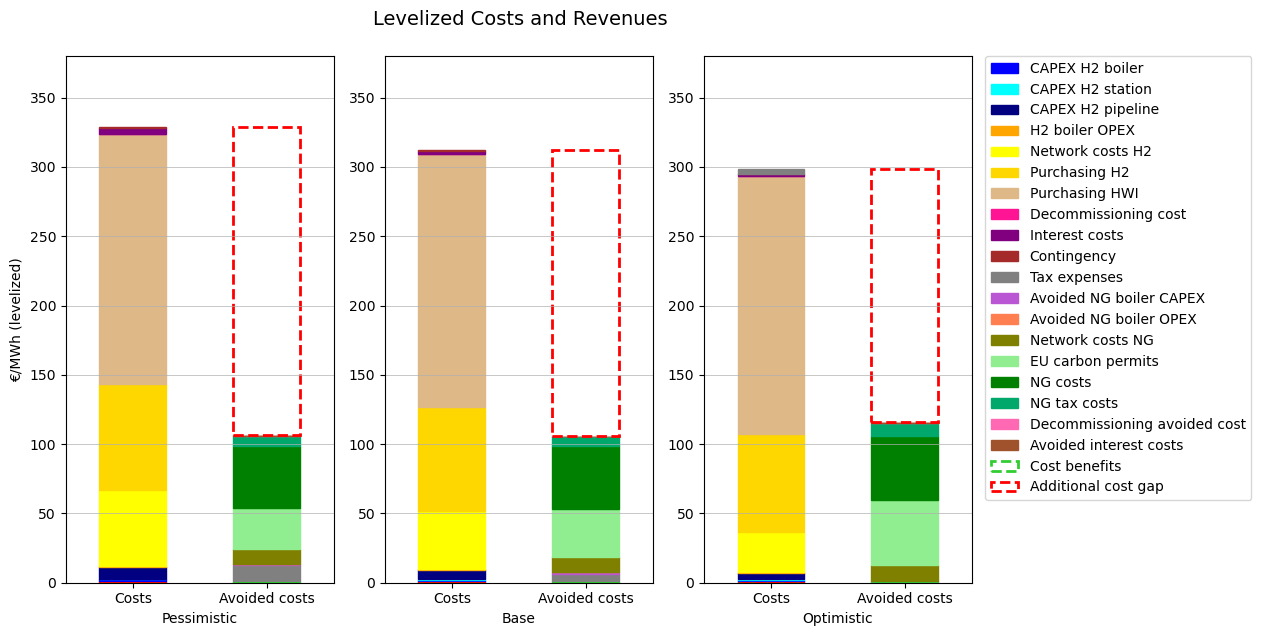

In [9]:
import matplotlib.pyplot as plt

# Define specific colors for each variable
color_mapping = {
    'CAPEX H2 boiler': 'blue',
    'CAPEX H2 station': 'cyan',
    'CAPEX H2 pipeline': 'navy',
    'H2 boiler OPEX': 'orange',
    'Network costs H2': 'yellow',
    'Purchasing H2': 'gold',
    'Purchasing HWI': 'burlywood',
    'Decommissioning cost': '#FF1493',
    'Interest costs': 'purple',
    'Contingency': 'brown',
    'Tax expenses': 'grey',
    'Avoided NG boiler CAPEX': 'mediumorchid',
    'Avoided NG boiler OPEX': '#FF7F50',
    'Network costs NG': 'olive',
    'EU carbon permits': 'lightgreen',
    'NG costs': 'green',
    'NG tax costs': '#00A86B',
    'Decommissioning avoided cost': '#FF69B4' ,
    'Avoided interest costs': 'sienna' ,
    'Cost benefits': 'limegreen',
    'Additional cost gap': 'red'  
}

# Plot levelized costs and revenues
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# plt.suptitle('Levelized Costs and Revenues')

# List of axes
axes = [ax1, ax2, ax3]

# Get column names
column_names = t_df_lcr_all_scenarios.columns

# Plot each scenario and apply custom colors
for ax, scenario in zip(axes, ['Pessimistic', 'Most likely', 'Optimistic']):
    xlabel = 'Base' if scenario == 'Most likely' else scenario
    plot = t_df_lcr_all_scenarios.loc[scenario].plot(
        kind='bar', stacked=True, ax=ax, rot='horizontal', legend=False,
        xlabel=xlabel, ylabel='€/MWh (levelized)' if ax == ax1 else None
    )
    
    # Iterate through bars and assign colors based on the variable name
    for i, bar in enumerate(ax.containers):
        for patch in bar:
            col_name = column_names[i]  # Get the corresponding column name
            
            if col_name == 'Additional cost gap':  # Apply dashed line 
                patch.set_edgecolor('red')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            elif col_name == "Cost benefits":
                patch.set_edgecolor('limegreen')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            else:
                # Use the color mapping for other variables
                patch.set_color(color_mapping.get(col_name, 'gray'))  # Default to gray if not found

# Add a custom title above the "Most likely" plot
fig.text(0.35, 1.02, 'Levelized Costs and Revenues', ha='center', va='bottom', fontsize=14)


# Add a single legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Apply grid and y-limit to all axes
for ax in axes:
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5)
    ax.set_ylim(0, 380)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend
plt.show()
